# 20260630 pairwise interaction — read-mapping validation

Same method as the [20260721 mapping_validation analysis](../../../20260721/analysis/mapping_validation/mapping_validation_20260721.ipynb),
run here via the shared, experiment-parameterized pipeline in `../../../shared_pipelines/`
(see `analysis/config.py` for this experiment's specific paths/references).

**Three structural differences from 20260721** (see `analysis/config.py` docstring):
- **Reads**: rather than one canonical demux directory, 20260630 had two parallel demux runs
  with no designated "final" one. The wells to analyze here are the ones the user curated
  and moved into `data/relevant_fastqs/`.
- **Reference**: `analysis/consensus2/strain_consensus_20260630.fasta` (84 strains) — the
  more recent/refined of two independent per-strain consensus builds. There is no
  mono-priority variant, because — per the user — **20260630 has no *true* mono-culture
  wells**, unlike 20260721. The `well_type == "mono"` label still exists in the layout, but
  shouldn't be read as a validated monoculture control the way 20260721's was.
- **No `_plate1_2_swapped` layout variant** exists for this experiment — the plain
  `strain_layout_20260630.csv` is used directly.

**Method** (unchanged): constrained edlib mapping (does a read match *only* the well's
expected strain(s)) + unconstrained minimap2 scan (what does an off-target read actually
look like — the contamination signature).


In [1]:
import sys
from pathlib import Path

NB_DIR = Path.cwd()
sys.path.insert(0, str(NB_DIR.parent))  # analysis/ (config.py lives here, shared by both pipelines)

import pandas as pd
from IPython.display import Image, display, Markdown

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

from config import CFG  # also puts shared_pipelines/ on sys.path as a side effect

OUT_DIR = CFG.mapping_validation_out_dir
FIG_DIR = CFG.mapping_validation_fig_dir

def show(png_name, width=880):
    display(Image(filename=str(FIG_DIR / png_name), width=width))

print(f"outputs -> {OUT_DIR}")
print(f"figures -> {FIG_DIR}")
print(f"reference dbs:")
for name, path in CFG.reference_dbs.items():
    print(f"  {name:32s} {path}")


outputs -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/mapping_validation/outputs
figures -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/mapping_validation/outputs/figures
reference dbs:
  corroborated_db                  /home/rl/scripts/karl/merge_consensus_sequences/collapse_naive_updated3_15diff/corroborated_db_filtered_min5.fasta
  consensus2                       /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/consensus2/strain_consensus_20260630.fasta


## Step 1 — which wells qualify?

Every well in the layout is resolved to its curated fastq in `data/relevant_fastqs/` and
read-counted. We keep wells with **more than 5 reads** (same threshold as 20260721). Most of
the layout's 9,120 wells have no file at all here — `data/relevant_fastqs/` only contains the
3,080 wells the user already curated as worth analyzing.


In [2]:
from mapping_validation import gather_samples

samples = gather_samples(CFG)


layout wells               : 9120
  missing fastq files      : 6040
wells with > 5 reads      : 2812
  well_type breakdown      : {'pair': 2778, 'mono': 34}
  total reads in cohort    : 117842
saved -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/mapping_validation/outputs/01_samples_gt5reads.csv


In [3]:
display(samples.head())
print()
print("well_type counts:", samples["well_type"].value_counts().to_dict())
print("mono wells with >5 reads:", (samples.well_type == "mono").sum())


,sample_id,dest_plate,dest_row,dest_col,dest_well,well_type,strain1,strain2,n_reads,path
0,Plate01_B10,1,B,10,B10,pair,P19,H23,67,/home/rl/scripts/karl/pairwise_interaction_exp...
1,Plate01_B11,1,B,11,B11,pair,G3,C20,65,/home/rl/scripts/karl/pairwise_interaction_exp...
2,Plate01_B12,1,B,12,B12,pair,H19,E2,87,/home/rl/scripts/karl/pairwise_interaction_exp...
3,Plate01_B13,1,B,13,B13,pair,G6,O11,67,/home/rl/scripts/karl/pairwise_interaction_exp...
4,Plate01_B14,1,B,14,B14,pair,G12,H17,73,/home/rl/scripts/karl/pairwise_interaction_exp...



well_type counts: {'pair': 2778, 'mono': 34}
mono wells with >5 reads: 34


## Step 2 — reference coverage, and an identity cross-check

Same cross-check as 20260721: for every strain, compare `corroborated_db`'s sequence to this
experiment's own consensus (`consensus2`) for the same name, since short plate-well-style
strain names get reused across unrelated experiments and a name match isn't automatically an
identity match.

**Result here is notably different from 20260721.** `corroborated_db` covers only 20/100
strains in this layout at all (vs. 87/87 for 20260721) — but of the 19 comparable strains,
**all 19 agree** with this experiment's own consensus (vs. 21/86 for 20260721). Where
`corroborated_db` does have an entry for a 20260630 strain, it appears to be trustworthy;
it's just much less complete here.


In [4]:
from mapping_validation import prepare_references

dbs, coverage, cross_check = prepare_references(CFG)


strains in layout: 100
  corroborated_db                  /home/rl/scripts/karl/merge_consensus_sequences/collapse_naive_updated3_15diff/corroborated_db_filtered_min5.fasta
    covers 20/100 strains, +67 extra entries not in this layout
  consensus2                       /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/consensus2/strain_consensus_20260630.fasta
    covers 84/100 strains
saved -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/mapping_validation/outputs/02_reference_coverage.csv

corroborated_db identity cross-check (19 strains comparable):
  19/19 strain names agree with this experiment's own consensus (< 0.1 normalized edit distance)
  0/19 strain names in corroborated_db do NOT match this experiment's sequence for that name -- likely coincidental reuse of a plate-well-style label from an unrelated experiment, not the same organism.
  -> treating consensus2 as the PRIMARY reference for QC calls; corroborated_db is repor

**19/19 strain names in `corroborated_db` agree with this experiment's own consensus** (all of the 19 comparable). `consensus2` is used as the primary reference throughout, both because it's self-consistent by construction and because it's the complete one (84/100 strains vs. corroborated_db's 20/100).

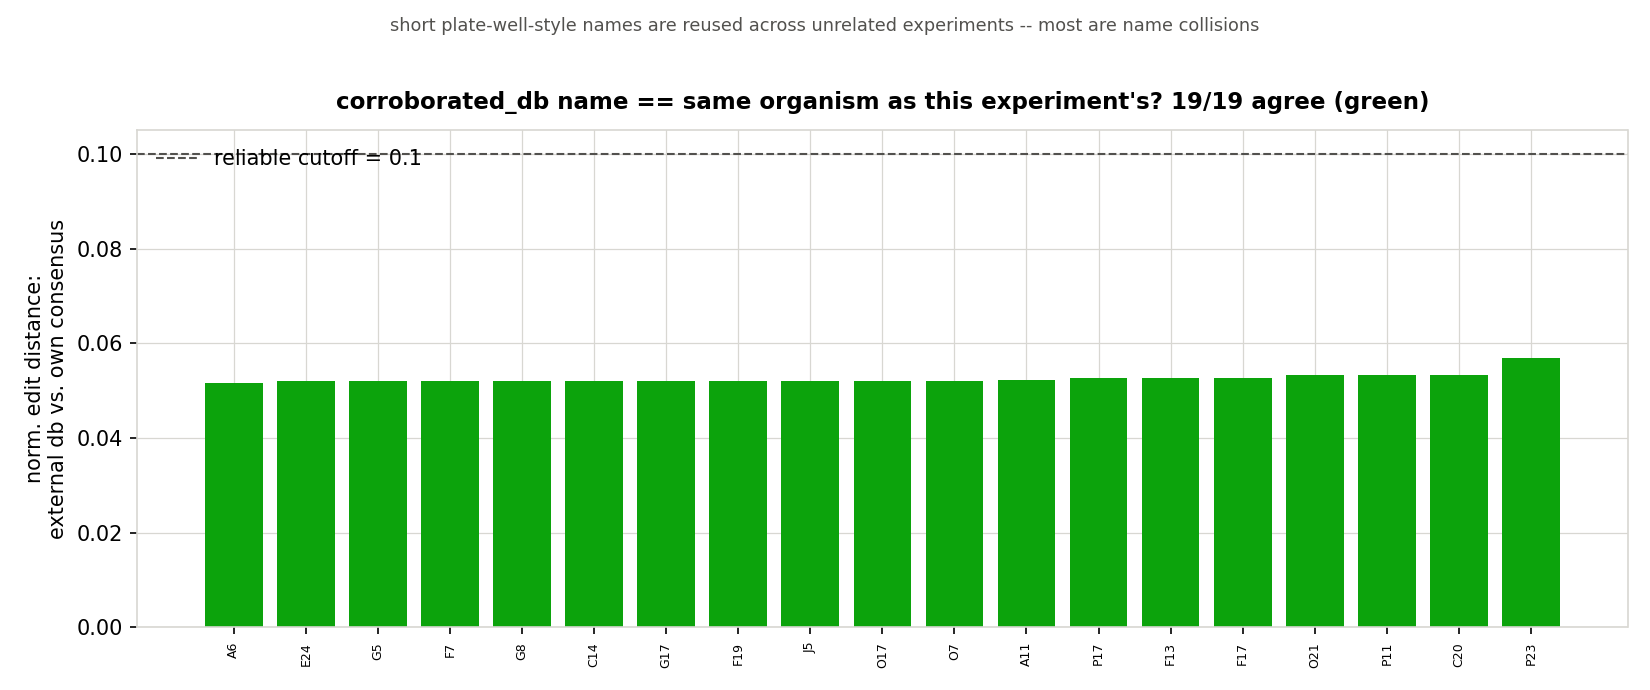

In [5]:
n_reliable = int(cross_check["reliable"].sum())
display(Markdown(
    f"**{n_reliable}/{len(cross_check)} strain names in `corroborated_db` agree with this "
    f"experiment's own consensus** (all of the {len(cross_check)} comparable). "
    "`consensus2` is used as the primary reference throughout, both because it's "
    "self-consistent by construction and because it's the complete one (84/100 strains vs. "
    "corroborated_db's 20/100)."
))
show("00_reference_reliability_check.png")


## Step 3 — constrained mapping: does each read match its expected strain(s)?

For every read in every qualifying well, edlib computes the normalized edit distance to each
candidate reference in each of the two databases.


In [6]:
from mapping_validation import constrained_edlib_mapping

edlib_results = constrained_edlib_mapping(CFG, samples)


[corroborated_db] 1045/2812 wells had a reference for >=1 expected strain (1767 skipped, no reference available); 44282 reads classified -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/mapping_validation/outputs/03_edlib_read_assignments_corroborated_db.csv.gz
[consensus2] 2747/2812 wells had a reference for >=1 expected strain (65 skipped, no reference available); 115590 reads classified -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/mapping_validation/outputs/03_edlib_read_assignments_consensus2.csv.gz


## Step 4 — unconstrained cross-check: minimap2 against every strain in a db

In [7]:
from mapping_validation import minimap2_contamination_scan

minimap2_results = minimap2_contamination_scan(CFG, samples)


[corroborated_db] 117846/117846 reads mapped (100.0%); 28311/117846 best-hit an expected strain (24.0%) -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/mapping_validation/outputs/04_minimap2_read_besthit_corroborated_db.csv
[consensus2] 117845/117845 reads mapped (100.0%); 55805/117845 best-hit an expected strain (47.4%) -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/mapping_validation/outputs/04_minimap2_read_besthit_consensus2.csv


## Step 5 — combine, QC-call every well, flag contamination

Same method as 20260721 (see that notebook / the shared pipeline's docstring for the full
rationale): a confident-match threshold is learned once from the primary db's pooled
distances and applied everywhere; a strain "counts" as present with
`max(3, 10% of reads)` confident reads; contamination candidates are annotated with how
similar the "contaminant" strain's own reference is to the well's expected strain(s), to
separate reference near-twin artifacts from real off-target signal.


In [8]:
from mapping_validation import combine_and_flag, REFERENCE_TWIN_THRESHOLD

summary = combine_and_flag(CFG)
PRIMARY_DB = CFG.primary_db


confident-match threshold (learned from consensus2, applied to all dbs): 0.125
combined summary: 2812 wells -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/mapping_validation/outputs/05_combined_sample_summary.csv

qc_status counts:
qc_status
pair_single_dominant      1565
pair_both_confirmed       1044
pair_neither_confirmed     169
mono_confirmed              26
mono_low_confidence          8

contamination-flagged wells: 1713 -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/mapping_validation/outputs/05_contamination_candidates.csv
  of which 1410 are reference near-twins (<0.05 dist to expected strain's own reference -- 16S can't discriminate these, likely not real contamination)
  303 involve a genuinely divergent unexpected strain -- higher-priority follow-up


In [9]:
qc_counts = summary.groupby(["well_type", "qc_status"]).size().rename("n_wells")
display(qc_counts.to_frame())


n_wells
well_type qc_status                      
mono      mono_confirmed               26
          mono_low_confidence           8
pair      pair_both_confirmed        1044
          pair_neither_confirmed      169
          pair_single_dominant       1565

**Mono wells confirm less cleanly here than in 20260721** (26/34 = 76%, vs. 26/26 = 100%
for 20260721) — consistent with the user's note that this experiment has no *true*
mono-culture wells; the `well_type == "mono"` label shouldn't be read as a validated
single-strain control the way it was for 20260721.


In [10]:
contam = pd.read_csv(OUT_DIR / "05_contamination_candidates.csv")
n_twin = int(contam["likely_reference_twin"].sum())
display(Markdown(
    f"**{len(contam)} wells flagged as contaminated.** {n_twin} are reference near-twins "
    f"(<{REFERENCE_TWIN_THRESHOLD} normalized edit distance between the 'contaminant' and the "
    f"well's own expected strain -- 16S can't tell these apart). **{len(contam) - n_twin} "
    "involve a genuinely divergent unexpected strain and are the higher-priority follow-up list.**"
))

genuine = contam[~contam.likely_reference_twin].sort_values(
    f"mm2_{PRIMARY_DB}_top_other_frac", ascending=False
)
display(genuine.head(15))


**1713 wells flagged as contaminated.** 1410 are reference near-twins (<0.05 normalized edit distance between the 'contaminant' and the well's own expected strain -- 16S can't tell these apart). **303 involve a genuinely divergent unexpected strain and are the higher-priority follow-up list.**

,sample_id,well_type,strain1,strain2,n_reads,mm2_consensus2_top_other_strain,mm2_consensus2_top_other_count,mm2_consensus2_top_other_frac,contaminant_ref_dist_to_expected,likely_reference_twin,qc_status
1,Plate07_E9,pair,P21,E5,41,G7,40,0.975610,NaN,False,pair_neither_confirmed
2,Plate13_I5,pair,E15,G11,32,G7,30,0.937500,NaN,False,pair_neither_confirmed
3,Plate17_B12,pair,E5,G11,43,G7,40,0.930233,NaN,False,pair_neither_confirmed
5,Plate11_J14,pair,G9,E5,25,G7,23,0.920000,0.213783,False,pair_neither_confirmed
6,Plate19_J15,pair,E15,A15,42,G7,38,0.904762,NaN,False,pair_neither_confirmed
7,Plate17_H6,pair,M9,E14,26,M17,23,0.884615,NaN,False,pair_neither_confirmed
9,Plate01_I13,pair,G11,E14,74,M17,64,0.864865,NaN,False,pair_neither_confirmed
10,Plate01_M18,pair,A15,E14,47,M17,40,0.851064,NaN,False,pair_neither_confirmed
11,Plate01_J12,pair,H11,E5,37,G7,31,0.837838,0.214487,False,pair_neither_confirmed
13,Plate17_F14,mono,P21,G23,30,A1,25,0.833333,NaN,False,mono_low_confidence


In [11]:
display(Markdown("**`pair_neither_confirmed`** — wells where the constrained mapping "
                  "found neither expected strain (top QC concern):"))
worst = summary[summary.qc_status == "pair_neither_confirmed"][
    ["sample_id", "well_type", "strain1", "strain2", "n_reads",
     f"mm2_{PRIMARY_DB}_top_other_strain", f"mm2_{PRIMARY_DB}_top_other_frac"]
].sort_values("n_reads", ascending=False)
display(worst.head(15))


**`pair_neither_confirmed`** — wells where the constrained mapping found neither expected strain (top QC concern):

,sample_id,well_type,strain1,strain2,n_reads,mm2_consensus2_top_other_strain,mm2_consensus2_top_other_frac
308,Plate03_B5,pair,E15,P21,84,G7,0.702381
889,Plate07_B2,pair,M9,A15,82,M17,0.304878
1065,Plate07_J3,pair,G13,E14,78,M17,0.653846
709,Plate05_H11,pair,A2,E8,76,A6,0.368421
147,Plate01_I13,pair,G11,E14,74,M17,0.864865
1762,Plate13_E20,pair,E15,G2,74,G21,0.378378
357,Plate03_E13,pair,M9,P21,72,A1,0.388889
857,Plate05_O10,pair,P19,A8,69,G7,0.521739
2807,Plate19_O3,pair,O13,E8,69,A1,0.333333
450,Plate03_I2,pair,A8,G2,67,G21,0.582090


## Step 6 — figures

In [12]:
from mapping_validation import make_all_figures

make_all_figures(CFG)


saved 7 figures -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260630/analysis/mapping_validation/outputs/figures


**Constrained mapping quality**:

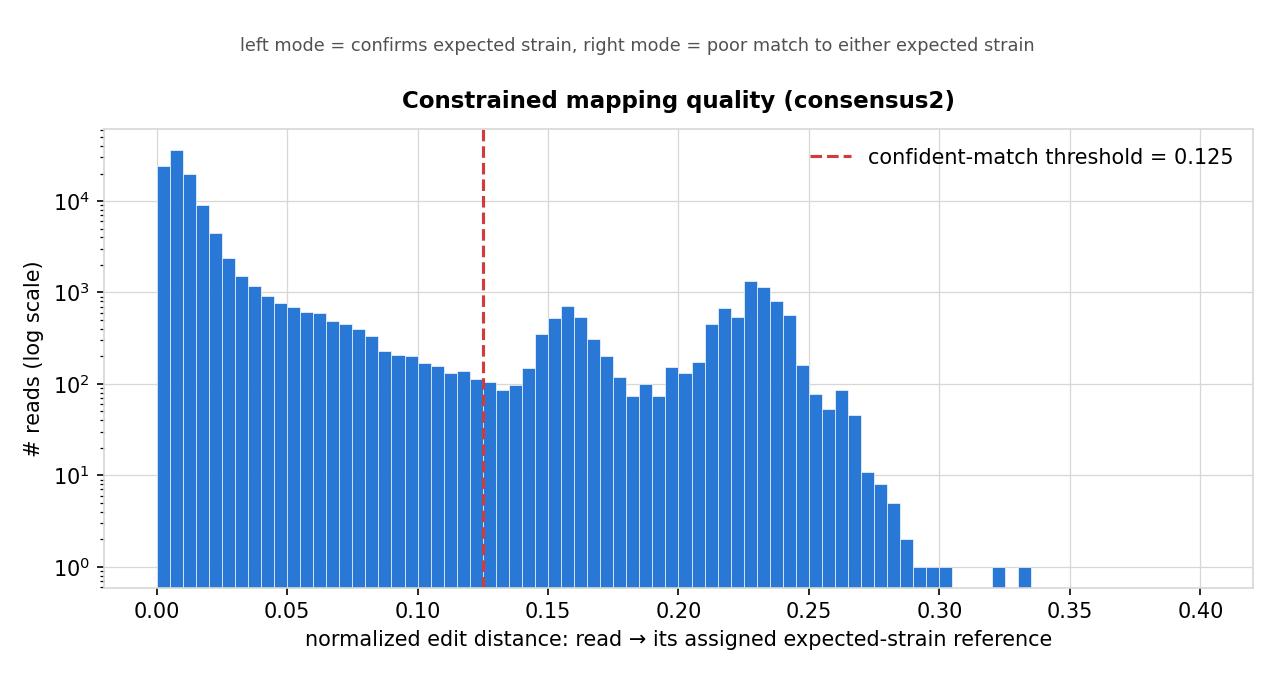

In [13]:
show("01_match_quality_histogram.png")

**QC call per well**, split by designed well type:

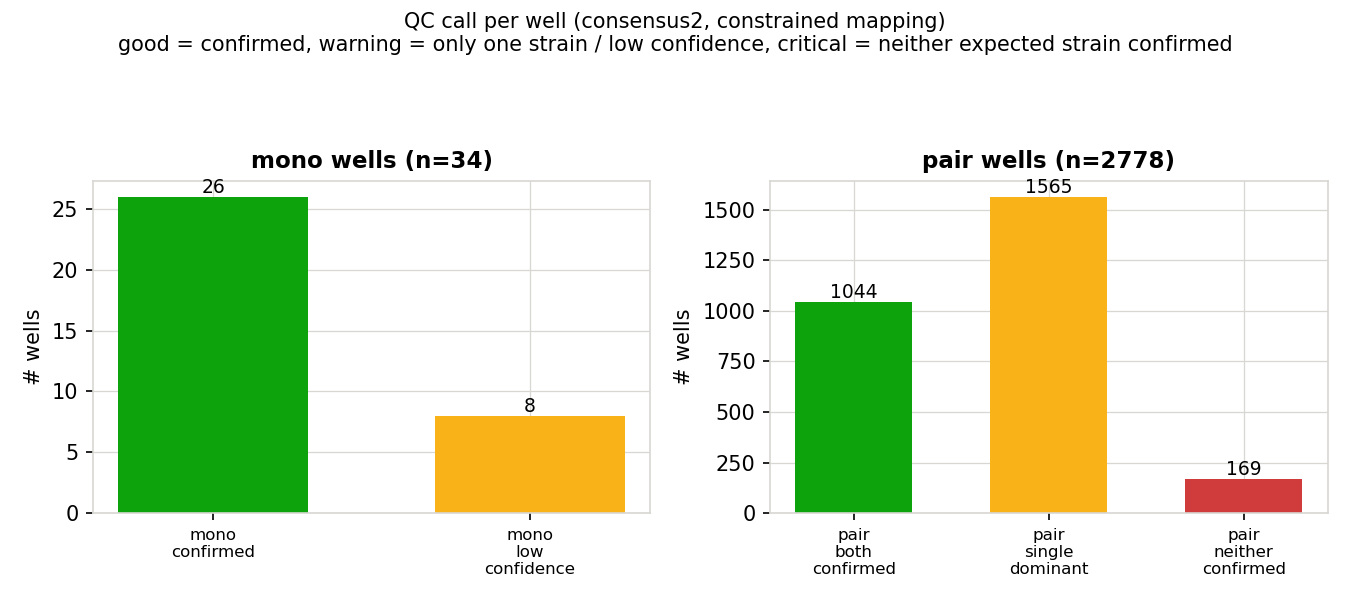

In [14]:
show("02_qc_status_by_well_type.png")

**Read purity**:

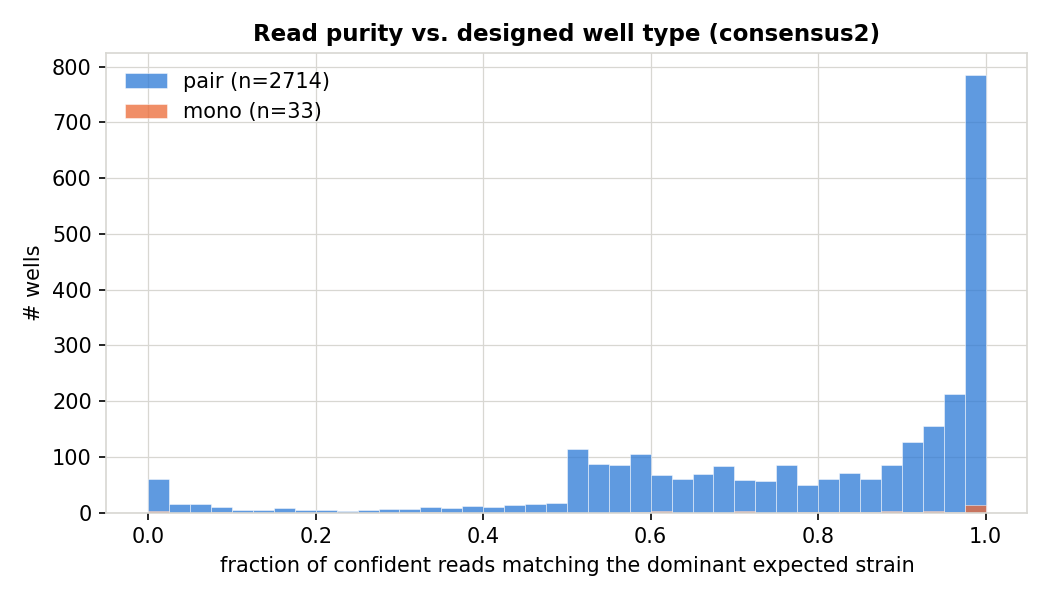

In [15]:
show("03_purity_histogram.png")

**Read depth vs. mapping confidence**:

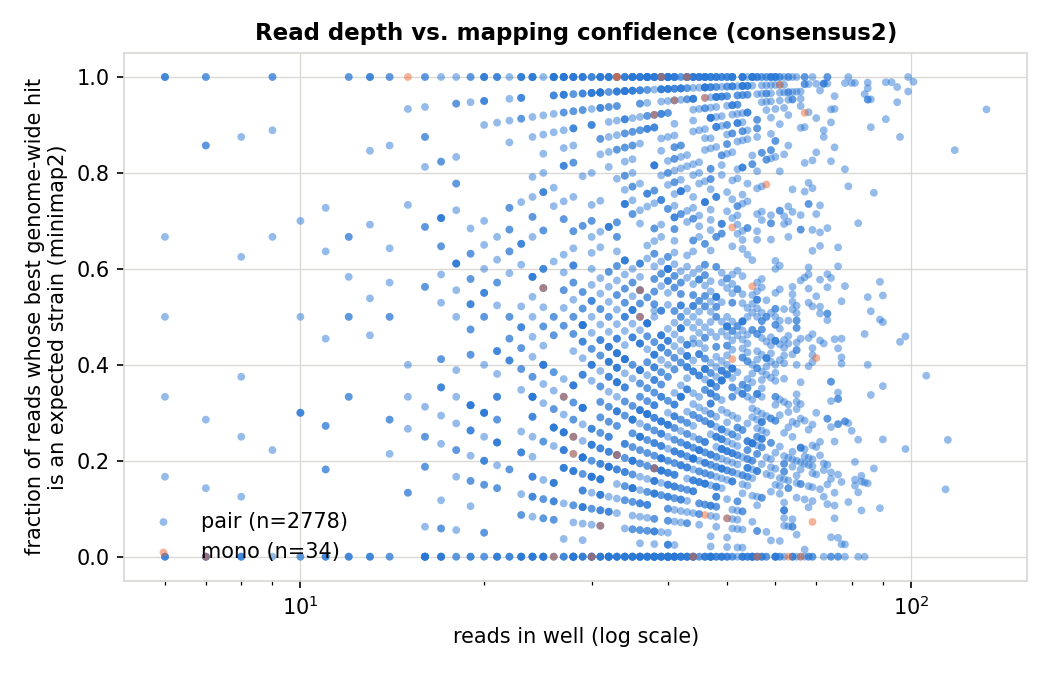

In [16]:
show("04_depth_vs_confidence.png")

**Independent vs. self-derived reference agreement**:

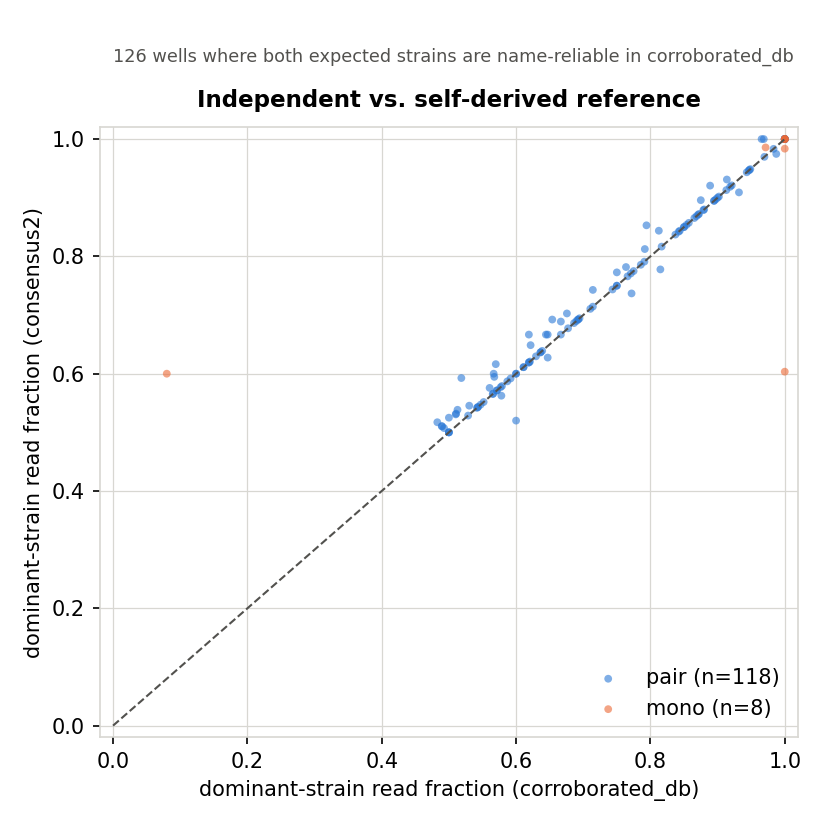

In [17]:
show("05_cross_db_agreement.png")

**Most frequent unexpected strains** (reference near-twins excluded):

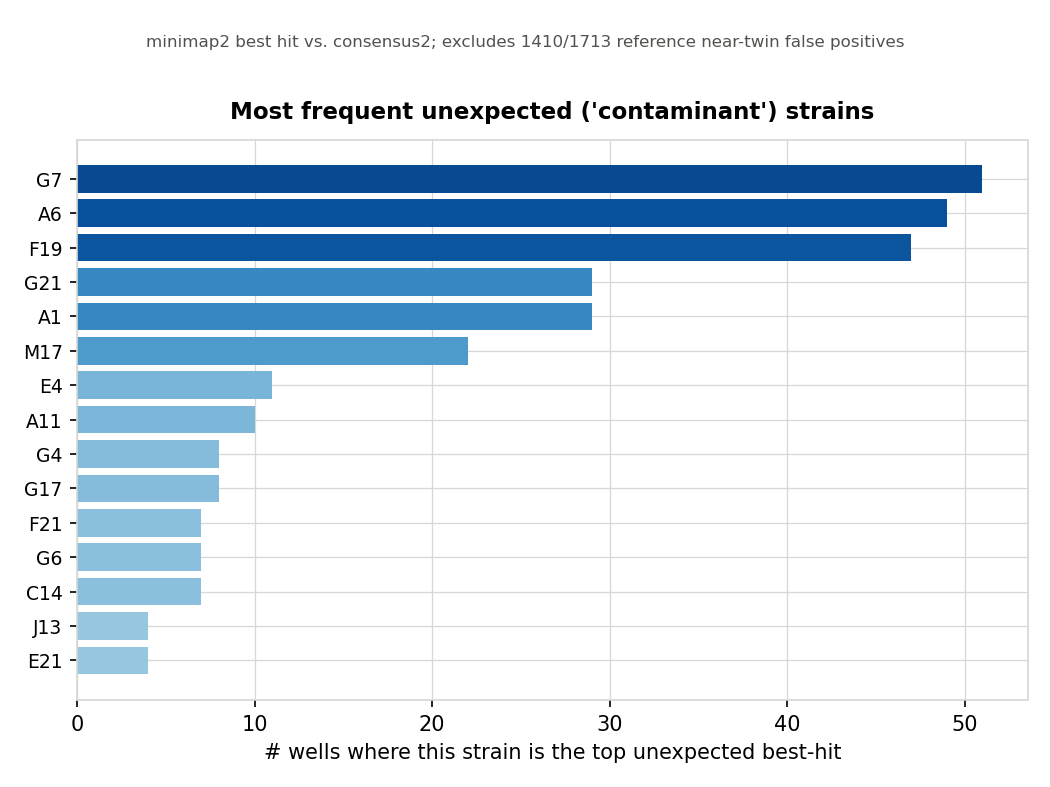

In [18]:
show("06_contamination_offenders.png")

## Key findings

1. **2,812 / 9,120 wells have more than 5 reads** in the curated `data/relevant_fastqs/`
   cohort (117,842 reads total); 34 are mono wells, 2,778 are pair wells.
2. **`corroborated_db` is far less complete here than for 20260721** (20/100 vs. 87/87
   strains have any entry at all) **but far more reliable where it does overlap** (19/19
   agree vs. 21/86 for 20260721) — the opposite trade-off from 20260721, worth keeping in
   mind if `corroborated_db` is used for other 20260630-adjacent work.
3. **Mono wells confirm at 76%** (26/34), notably below 20260721's 100% — consistent with
   the user's note that this experiment has no verified true monocultures.
4. **Pair wells**: 1,044/2,778 (38%) confirm both expected strains; 1,565 (56%) confirm only
   one; 169 (6%) confirm neither — a higher unresolved rate than 20260721's 1.4%, likely
   reflecting both the messier reference coverage (only 84/100 strains have a reference at
   all) and the higher rate of near-identical reference clusters in this strain set (see the
   relative_abundance notebook's step 1).
5. **Contamination scan**: 1,713 wells flagged; 1,410 (82%) are reference near-twins, leaving
   **303 genuine candidates** for follow-up.

## Where everything lives

```
analysis/
├── config.py                              this experiment's ExperimentConfig
├── mapping_validation/
│   ├── scripts/                           thin wrappers over ../../../shared_pipelines/mapping_validation.py
│   ├── outputs/                           same file layout as 20260721's mapping_validation/outputs/
│   └── <this notebook>
└── relative_abundance/                    see that notebook for interaction scoring + hierarchy analysis
```

Re-running this notebook top to bottom regenerates every output from `data/relevant_fastqs/`.


## todo

check against /home/rl/scripts/karl/merge_consensus_sequences/collapse_naive_updated3_15diff/corroborated_db_filtered.fasta not just the database filtered down to differentiable strains